In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('Data/retail_store_sales_promotions_demand.csv')

In [4]:
df.head()

,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Friday
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Wednesday
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Saturday
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Tuesday
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Saturday


In [5]:
df.shape

(2800, 10)

In [6]:
df.columns

Index(['store_id', 'product_id', 'date', 'category', 'price',
       'promotion_active', 'discount_percent', 'units_sold', 'inventory_level',
       'day_of_week'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   store_id          2800 non-null   int64 
 1   product_id        2800 non-null   int64 
 2   date              2800 non-null   object
 3   category          2800 non-null   object
 4   price             2800 non-null   int64 
 5   promotion_active  2800 non-null   object
 6   discount_percent  2800 non-null   int64 
 7   units_sold        2800 non-null   int64 
 8   inventory_level   2800 non-null   int64 
 9   day_of_week       2800 non-null   object
dtypes: int64(6), object(4)
memory usage: 218.9+ KB


In [8]:
df.describe()

,store_id,product_id,price,discount_percent,units_sold,inventory_level
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,25.381429,1495.836429,1518.536786,6.844643,26.290000,254.571429
std,14.217981,290.054812,846.448062,9.643473,11.378834,139.007945
min,1.000000,1000.000000,50.000000,0.000000,1.000000,20.000000
25%,13.000000,1242.000000,792.750000,0.000000,17.000000,134.000000
50%,25.000000,1497.500000,1533.000000,0.000000,26.000000,254.500000
75%,38.000000,1750.250000,2246.250000,15.000000,35.000000,376.250000
max,50.000000,2000.000000,3000.000000,30.000000,56.000000,500.000000


In [9]:
df.isnull().sum()

store_id            0
product_id          0
date                0
category            0
price               0
promotion_active    0
discount_percent    0
units_sold          0
inventory_level     0
day_of_week         0
dtype: int64

In [10]:
df.isna().sum()

store_id            0
product_id          0
date                0
category            0
price               0
promotion_active    0
discount_percent    0
units_sold          0
inventory_level     0
day_of_week         0
dtype: int64

In [11]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
df['date']

0      2024-09-19
1      2024-12-21
2      2024-09-27
3      2024-06-16
4      2024-12-05
          ...    
2795   2024-11-09
2796   2024-08-09
2797   2024-12-19
2798   2024-08-18
2799   2024-03-01
Name: date, Length: 2800, dtype: datetime64[ns]

In [13]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

# Cyclical encoding (captures seasonality smoothly)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)


In [14]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

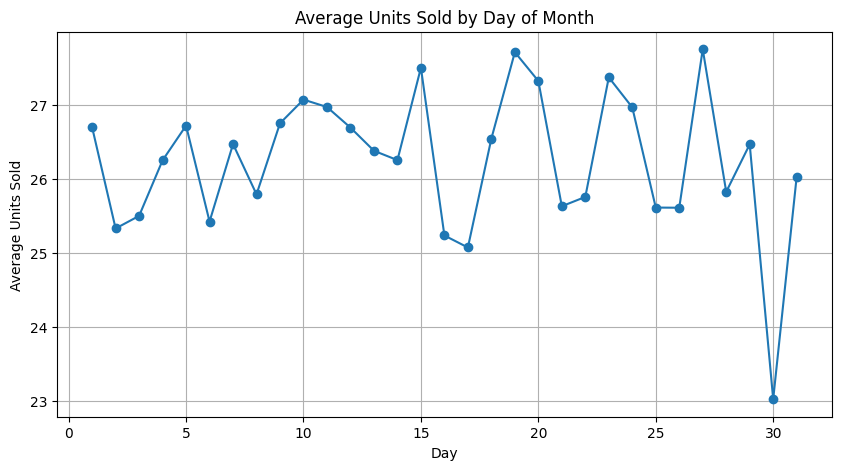

In [15]:
df.groupby('day')['units_sold'].mean().plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Average Units Sold by Day of Month")
plt.xlabel("Day")
plt.ylabel("Average Units Sold")
plt.grid(True)
plt.show()

In [16]:
df.head()

,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,year,month,day,day_of_year,week_of_year,month_sin,month_cos,dow_sin,dow_cos,is_weekend
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Friday,2024,9,19,263,38,-1.000000e+00,-1.836970e-16,0.433884,-0.900969,0
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Wednesday,2024,12,21,356,51,-2.449294e-16,1.000000e+00,-0.974928,-0.222521,0
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Saturday,2024,9,27,271,39,-1.000000e+00,-1.836970e-16,-0.433884,-0.900969,1
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Tuesday,2024,6,16,168,24,1.224647e-16,-1.000000e+00,-0.781831,0.623490,0
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Saturday,2024,12,5,340,49,-2.449294e-16,1.000000e+00,0.433884,-0.900969,1


In [17]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5, 6]:
        return "Summer"
    elif month in [7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

In [18]:
df['season'] = df['month'].apply(get_season)

In [19]:
def is_holiday_season(month):
    if month in [1]:        # New Year, Makar Sankranti
        return 1
    elif month in [8]:      # Raksha Bandhan, Janmashtami
        return 1
    elif month in [10, 11]: # Navratri, Dussehra, Diwali
        return 1
    elif month in [12]:     # Christmas, Year End
        return 1
    else:
        return 0

In [20]:
df['is_holiday_season'] = df.apply(lambda x: is_holiday_season(x['month']), axis=1)

In [21]:
# ---- Major Indian festivals for 2024 (the year covered by this dataset) ----
# Extend this list if you add data for other years.
festival_dates = pd.to_datetime([
    "2024-01-01",  # New Year
    "2024-01-26",  # Republic Day
    "2024-03-25",  # Holi
    "2024-08-15",  # Independence Day
    "2024-08-19",  # Raksha Bandhan
    "2024-09-07",  # Ganesh Chaturthi
    "2024-10-02",  # Gandhi Jayanti
    "2024-10-12",  # Dussehra
    "2024-11-01",  # Diwali
    "2024-11-15",  # Bhai Dooj
    "2024-12-25",  # Christmas
])

festival_set = set(festival_dates)

df['is_festival'] = df['date'].isin(festival_set).astype(int)

# Festival "window": +/- 3 days around a festival (pre/post shopping rush)
window = 3
festival_window_set = set()
for d in festival_dates:
    for offset in range(-window, window + 1):
        festival_window_set.add(d + pd.Timedelta(days=offset))

df['is_festival_window'] = df['date'].isin(festival_window_set).astype(int)

# Broader month-level holiday season flag (kept, but now secondary)
def is_holiday_season(month):
    return 1 if month in [1, 8, 10, 11, 12] else 0

df['is_holiday_season'] = df['month'].apply(is_holiday_season)

print(df[['is_festival', 'is_festival_window', 'is_holiday_season']].sum())

is_festival             79
is_festival_window     516
is_holiday_season     1202
dtype: int64


In [22]:
df.head()

,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,...,week_of_year,month_sin,month_cos,dow_sin,dow_cos,is_weekend,season,is_holiday_season,is_festival,is_festival_window
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Friday,...,38,-1.000000e+00,-1.836970e-16,0.433884,-0.900969,0,Monsoon,0,0,0
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Wednesday,...,51,-2.449294e-16,1.000000e+00,-0.974928,-0.222521,0,Winter,1,0,0
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Saturday,...,39,-1.000000e+00,-1.836970e-16,-0.433884,-0.900969,1,Monsoon,0,0,0
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Tuesday,...,24,1.224647e-16,-1.000000e+00,-0.781831,0.623490,0,Summer,0,0,0
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Saturday,...,49,-2.449294e-16,1.000000e+00,0.433884,-0.900969,1,Winter,1,0,0


In [23]:
print("Number of Stores:", df['store_id'].nunique())
print("Number of Products:", df['product_id'].nunique())
print("Number of Categories:", df['category'].nunique())

Number of Stores: 50
Number of Products: 947
Number of Categories: 5


In [24]:
products_per_category = (
    df.groupby('category')['product_id']
      .nunique()
      .sort_values(ascending=False)
)

print(products_per_category)

category
Grocery          447
Home             442
Personal Care    440
Clothing         429
Electronics      422
Name: product_id, dtype: int64


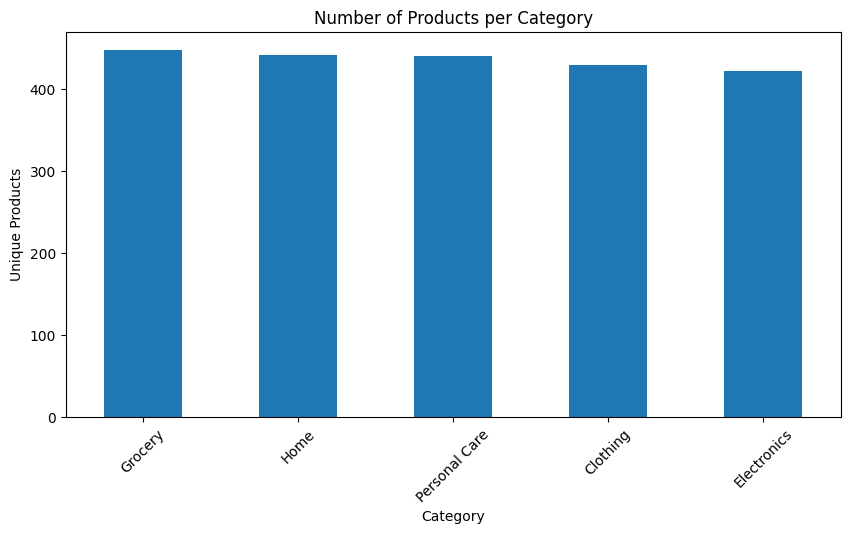

In [25]:
products_per_category.plot(kind='bar', figsize=(10,5))
plt.title('Number of Products per Category')
plt.xlabel('Category')
plt.ylabel('Unique Products')
plt.xticks(rotation=45)
plt.show()

In [26]:
df['product_freq'] = (
    df.groupby('product_id')['product_id']
      .transform('count')
)

In [27]:
df.columns

Index(['store_id', 'product_id', 'date', 'category', 'price',
       'promotion_active', 'discount_percent', 'units_sold', 'inventory_level',
       'day_of_week', 'year', 'month', 'day', 'day_of_year', 'week_of_year',
       'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'season',
       'is_holiday_season', 'is_festival', 'is_festival_window',
       'product_freq'],
      dtype='object')

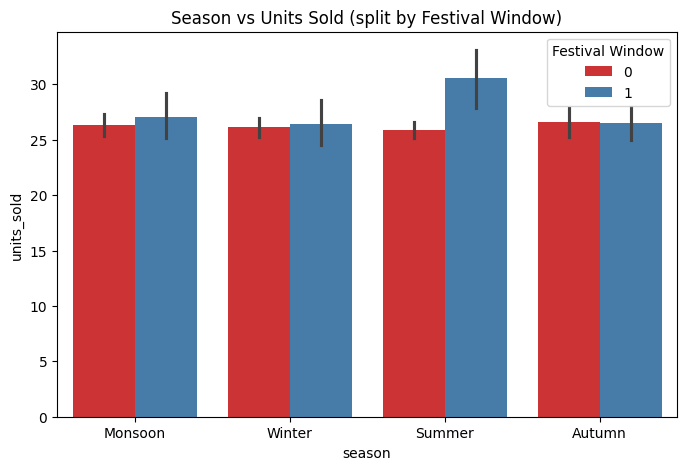

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='units_sold', data=df, hue='is_festival_window', palette='Set1')
plt.title("Season vs Units Sold (split by Festival Window)")
plt.legend(title='Festival Window')
plt.show()

In [29]:
df['is_promotion_active'] = (df['promotion_active'] == 'Yes').astype(int)
df['price_discount_ratio'] = df['price'] * (df['discount_percent'] / 100)
df['effective_price'] = df['price'] - df['price_discount_ratio']

In [30]:
df = df.sort_values(['store_id', 'product_id', 'date']).reset_index(drop=True)

grp = df.groupby(['store_id', 'product_id'])['units_sold']

df['units_sold_lag_1']      = grp.shift(1)
df['units_sold_lag_7']      = grp.shift(7)
df['units_sold_roll_mean_7'] = grp.transform(lambda x: x.shift(1).rolling(7).mean())

# First few rows per product/store won't have lag values -> fill with group mean as a safe default
for col in ['units_sold_lag_1', 'units_sold_lag_7', 'units_sold_roll_mean_7']:
    df[col] = df[col].fillna(df.groupby(['store_id','product_id'])['units_sold'].transform('mean'))

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   store_id                2800 non-null   int64         
 1   product_id              2800 non-null   int64         
 2   date                    2800 non-null   datetime64[ns]
 3   category                2800 non-null   object        
 4   price                   2800 non-null   int64         
 5   promotion_active        2800 non-null   object        
 6   discount_percent        2800 non-null   int64         
 7   units_sold              2800 non-null   int64         
 8   inventory_level         2800 non-null   int64         
 9   day_of_week             2800 non-null   object        
 10  year                    2800 non-null   int32         
 11  month                   2800 non-null   int32         
 12  day                     2800 non-null   int32   

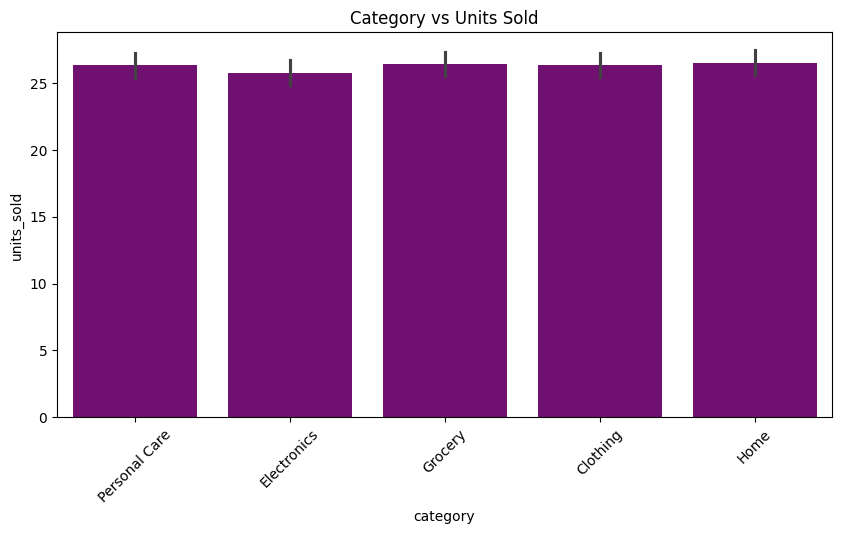

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(x='category', y='units_sold', data=df ,color='purple')
plt.xticks(rotation=45)
plt.title("Category vs Units Sold")
plt.show()


In [33]:
df.columns

Index(['store_id', 'product_id', 'date', 'category', 'price',
       'promotion_active', 'discount_percent', 'units_sold', 'inventory_level',
       'day_of_week', 'year', 'month', 'day', 'day_of_year', 'week_of_year',
       'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'season',
       'is_holiday_season', 'is_festival', 'is_festival_window',
       'product_freq', 'is_promotion_active', 'price_discount_ratio',
       'effective_price', 'units_sold_lag_1', 'units_sold_lag_7',
       'units_sold_roll_mean_7'],
      dtype='object')

In [34]:
# Numerical Columns
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Categorical Columns
cat_cols = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)


Numerical Columns:
['store_id', 'product_id', 'price', 'discount_percent', 'units_sold', 'inventory_level', 'week_of_year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday_season', 'is_festival', 'is_festival_window', 'product_freq', 'is_promotion_active', 'price_discount_ratio', 'effective_price', 'units_sold_lag_1', 'units_sold_lag_7', 'units_sold_roll_mean_7']

Categorical Columns:
['category', 'promotion_active', 'day_of_week', 'season']


In [35]:
df = pd.get_dummies(
    df,
    columns=[
        'category',
        'day_of_week',
        'season'
    ],
    drop_first=True,
    dtype=int
)

In [36]:
df['promotion_active'] = (df['promotion_active'] == 'Yes').astype(int)

In [37]:
df.head()

,store_id,product_id,date,price,promotion_active,discount_percent,units_sold,inventory_level,year,month,...,category_Personal Care,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,season_Monsoon,season_Summer,season_Winter
0,1,1013,2024-09-12,128,0,0,6,397,2024,9,...,1,1,0,0,0,0,0,1,0,0
1,1,1043,2024-10-30,1487,1,15,27,468,2024,10,...,0,1,0,0,0,0,0,0,0,0
2,1,1053,2024-03-04,1128,1,5,35,207,2024,3,...,0,0,0,0,0,0,0,0,1,0
3,1,1064,2024-07-21,2823,1,10,36,131,2024,7,...,0,0,0,0,0,0,1,1,0,0
4,1,1091,2024-01-10,1424,0,0,36,350,2024,1,...,1,0,0,0,1,0,0,0,0,1


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   store_id                2800 non-null   int64         
 1   product_id              2800 non-null   int64         
 2   date                    2800 non-null   datetime64[ns]
 3   price                   2800 non-null   int64         
 4   promotion_active        2800 non-null   int64         
 5   discount_percent        2800 non-null   int64         
 6   units_sold              2800 non-null   int64         
 7   inventory_level         2800 non-null   int64         
 8   year                    2800 non-null   int32         
 9   month                   2800 non-null   int32         
 10  day                     2800 non-null   int32         
 11  day_of_year             2800 non-null   int32         
 12  week_of_year            2800 non-null   int64   

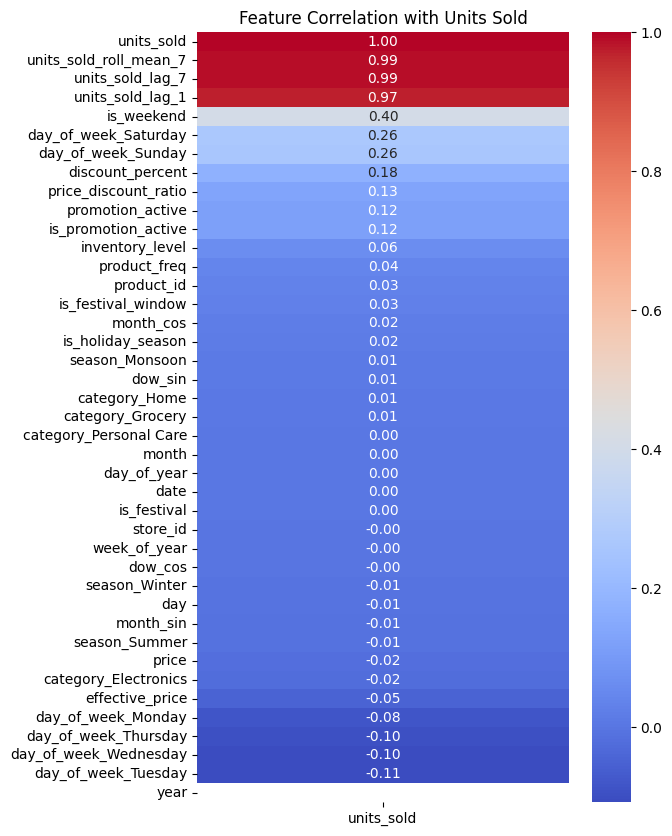

In [39]:
target_corr = df.corr()[['units_sold']].sort_values(
    by='units_sold',
    ascending=False
)

plt.figure(figsize=(6,10))

sns.heatmap(
    target_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Feature Correlation with Units Sold")

plt.show()

In [40]:
df.columns

Index(['store_id', 'product_id', 'date', 'price', 'promotion_active',
       'discount_percent', 'units_sold', 'inventory_level', 'year', 'month',
       'day', 'day_of_year', 'week_of_year', 'month_sin', 'month_cos',
       'dow_sin', 'dow_cos', 'is_weekend', 'is_holiday_season', 'is_festival',
       'is_festival_window', 'product_freq', 'is_promotion_active',
       'price_discount_ratio', 'effective_price', 'units_sold_lag_1',
       'units_sold_lag_7', 'units_sold_roll_mean_7', 'category_Electronics',
       'category_Grocery', 'category_Home', 'category_Personal Care',
       'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday',
       'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday',
       'season_Monsoon', 'season_Summer', 'season_Winter'],
      dtype='object')

In [41]:
selected_features = [

    # Historical Demand
    'units_sold_lag_1',
    'units_sold_roll_mean_7',

    # Pricing
    'discount_percent',
    'effective_price',

    # Inventory
    'inventory_level',

    # Product
    'product_freq',

    'category_Electronics',
    'category_Grocery',
    'category_Home',
    'category_Personal Care',

    # Calendar
    'day_of_week_Saturday',
    'day_of_week_Sunday',
    'month_sin',
    'month_cos',

    # Festival
    'is_festival_window'
]

In [42]:
X = df[selected_features]
y = df['units_sold']

In [43]:

split_date = df['date'].quantile(0.8, interpolation='lower')

train_idx = df['date'] <= split_date
test_idx  = df['date'] >  split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train rows:", X_train.shape[0], " Test rows:", X_test.shape[0])

Train rows: 2240  Test rows: 560


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

TRAINING MULTIPLE MODELS

In [45]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [46]:
lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [47]:
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
lr_pred = lr.predict(X_test_scaled)

rf_pred = rf.predict(X_test)

In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [51]:
print("Linear Regression")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2:",
      r2_score(y_test, lr_pred))

Linear Regression
MAE: 0.13128639282397886
RMSE: 0.30557200545765095
R2: 0.9992517605398106


In [52]:
print("Random Forest")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2:",
      r2_score(y_test, rf_pred))

Random Forest
MAE: 0.37119642857142854
RMSE: 1.3667417589706863
R2: 0.9850312199507798


In [53]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ]
})

results

,Model,R2,MAE
0,Linear Regression,0.999252,0.131286
1,Random Forest,0.985031,0.371196


In [54]:
from sklearn.metrics import r2_score

# Linear Regression
print(
    "Train R²:",
    r2_score(y_train, lr.predict(X_train_scaled))
)

print(
    "Test R²:",
    r2_score(y_test, lr.predict(X_test_scaled))
)


Train R²: 0.9870536973633098
Test R²: 0.9992517605398106


In [55]:
import joblib

joblib.dump(
    lr,
    "Models/Linear_Regression.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [56]:
joblib.dump(
    X.columns.tolist(),
    "Models/columns.pkl"
)

print("Columns Saved Successfully")

Columns Saved Successfully


In [57]:
joblib.dump(
    scaler,
    "Models/scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully
